# Spot making, bg making, and diffusion testing

In [1]:
import os; from os import listdir; from os.path import isfile, join
import re  
from skimage.io import imread
from skimage.exposure import rescale_intensity
import numpy as np 
from tqdm.notebook import tqdm
from timeit import default_timer as timer
import scipy
import pandas as pd
import shutil
import pathlib
import sys
import seaborn as sns
from skimage.measure import approximate_polygon
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

import os
homedir = os.getcwd()
os.chdir(homedir)
os.chdir('../../rsnapsim/')
import rsnapsim as rsnp
os.chdir(homedir)

import scipy.stats as stats
import matplotlib.pyplot as plt 

plt.style.use("dark_background")

# Defining directories
current_dir = pathlib.Path().absolute()
sequences_dir = current_dir.parents[0].joinpath('DataBases','gene_files')
video_dir = current_dir.parents[0].joinpath('DataBases','videos_for_sim_cell')
rsnaped_dir = current_dir.parents[0].joinpath('rsnaped')
gene_file = current_dir.parents[0].joinpath('DataBases','gene_files','KDM5B_withTags.txt')
masks_dir = current_dir.parents[0].joinpath('DataBases','masks_for_sim_cell')

# Importing rSNAPed
sys.path.append(str(rsnaped_dir))
import rsnaped as rsp

['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
eigen instillation found...
['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']
['C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\', 'C:\\Users\\willi\\anaconda3\\envs\\py312\\Library\\include\\']


C:\Users\willi\Documents\GitHub\rsnaped\rsnaped\rsnaped.py:2329: SyntaxWarning: invalid escape sequence '\m'
  '''
C:\Users\willi\Documents\GitHub\rsnaped\rsnaped\rsnaped.py:2399: SyntaxWarning: invalid escape sequence '\m'
  '''
C:\Users\willi\Documents\GitHub\rsnaped\rsnaped\rsnaped.py:5229: SyntaxWarning: invalid escape sequence '\D'
  list_files_names.sort(key=lambda f: int(re.sub('\D', '', f)))  # sorting the index in numerical order
C:\Users\willi\Documents\GitHub\rsnaped\rsnaped\rsnaped.py:5231: SyntaxWarning: invalid escape sequence '\D'
  path_files.sort(key=lambda f: int(re.sub('\D', '', f)))  # sorting the index in numerical order


Problems importing cellpose


# Spot Generation

<Figure size 1920x1440 with 0 Axes>

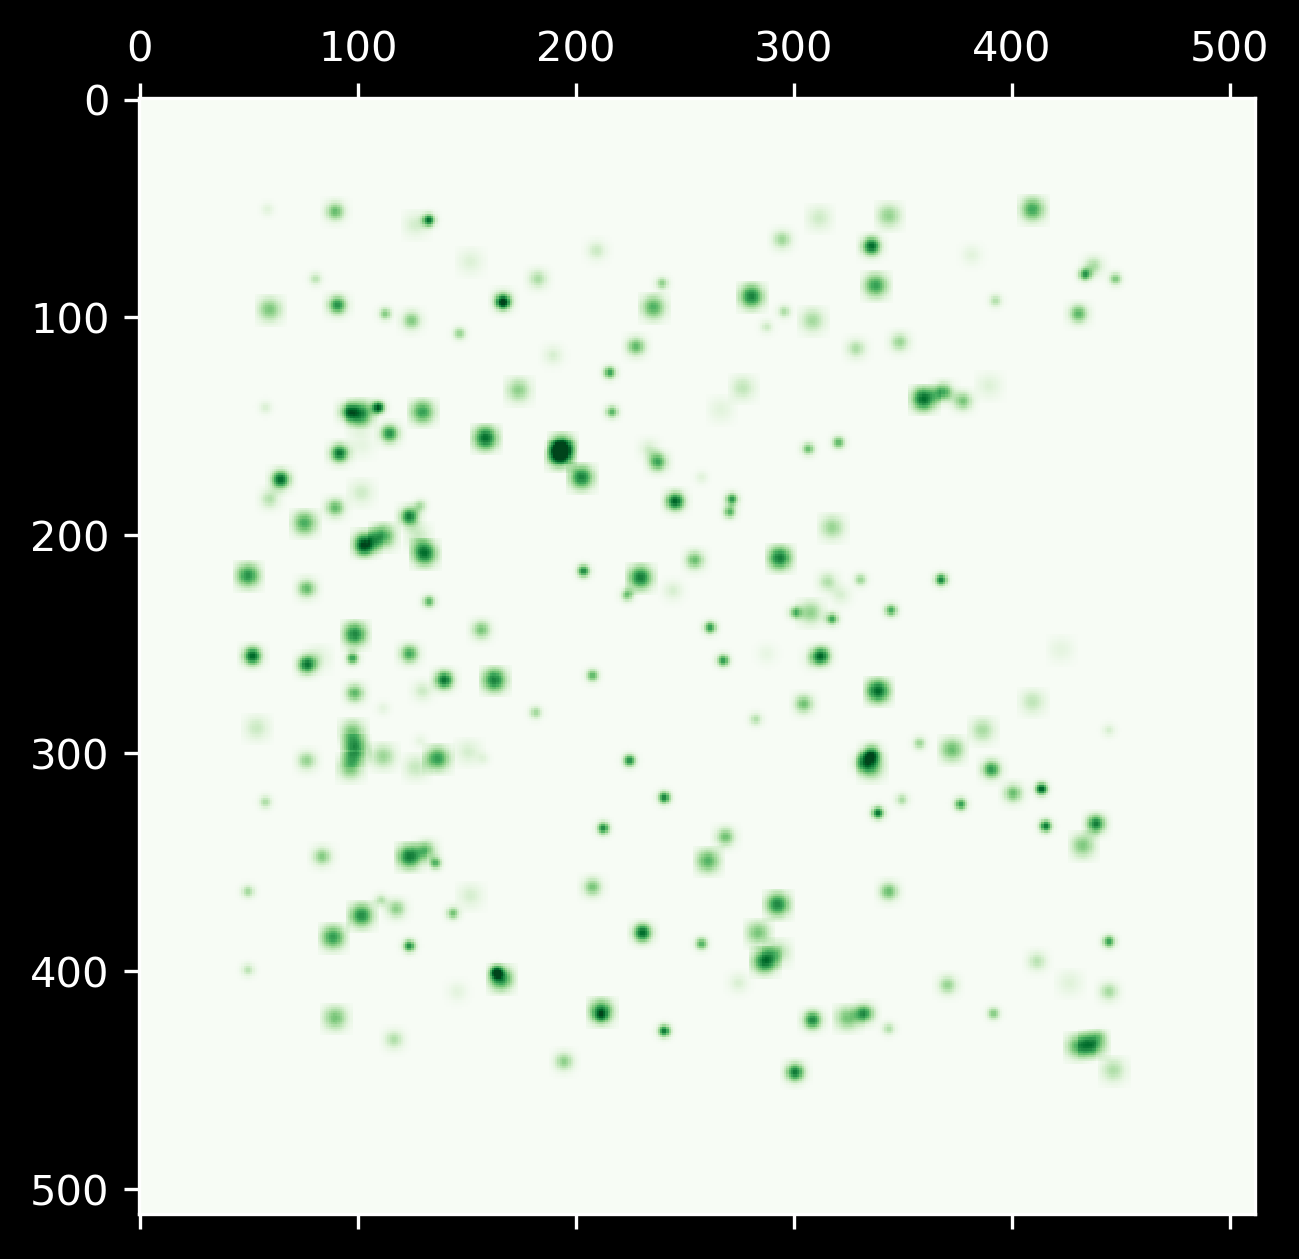

In [5]:
image = np.zeros([512,512],dtype=np.uint16);
spots_xy = np.random.randint(50,450,size=[200,2])
values_xy = np.random.randint(50,450,size=[200])
sigma = np.random.randint(2,5,size=[200])
spot_size = 15
intensity_scale = 10

frame = rsp.Frame2D().make(spots_xy, values_xy, spot_size, sigma,
         image, intensity_scale, poisson_sample_spot=True, photon_count=1e6)

plt.figure(dpi=300)
plt.matshow(frame, vmax=5000, cmap='Greens')

Text(0.5, 1.0, 'photon count = 464.1588833612782')

<Figure size 1920x1440 with 0 Axes>

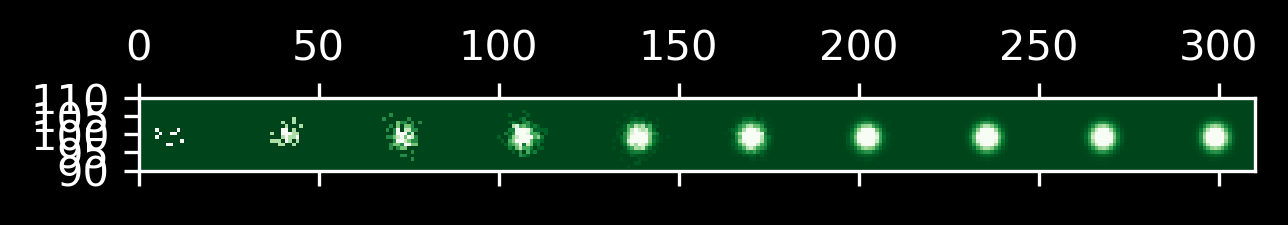

<Figure size 1920x1440 with 0 Axes>

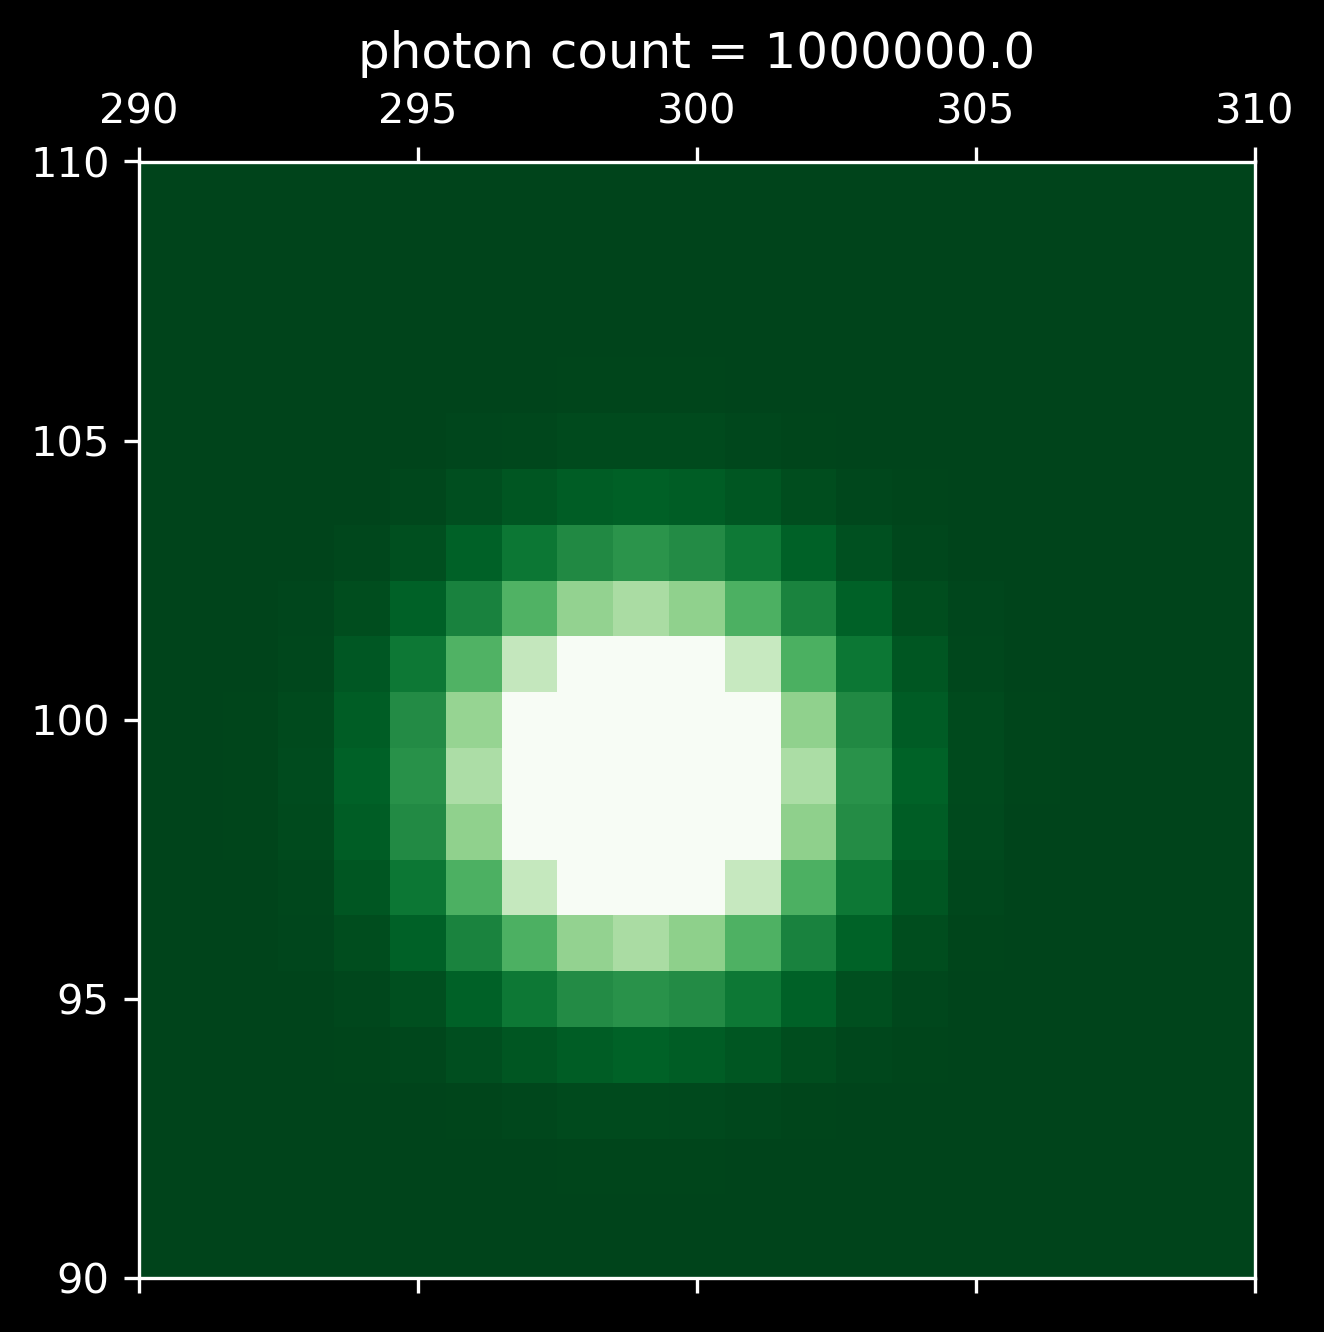

<Figure size 1920x1440 with 0 Axes>

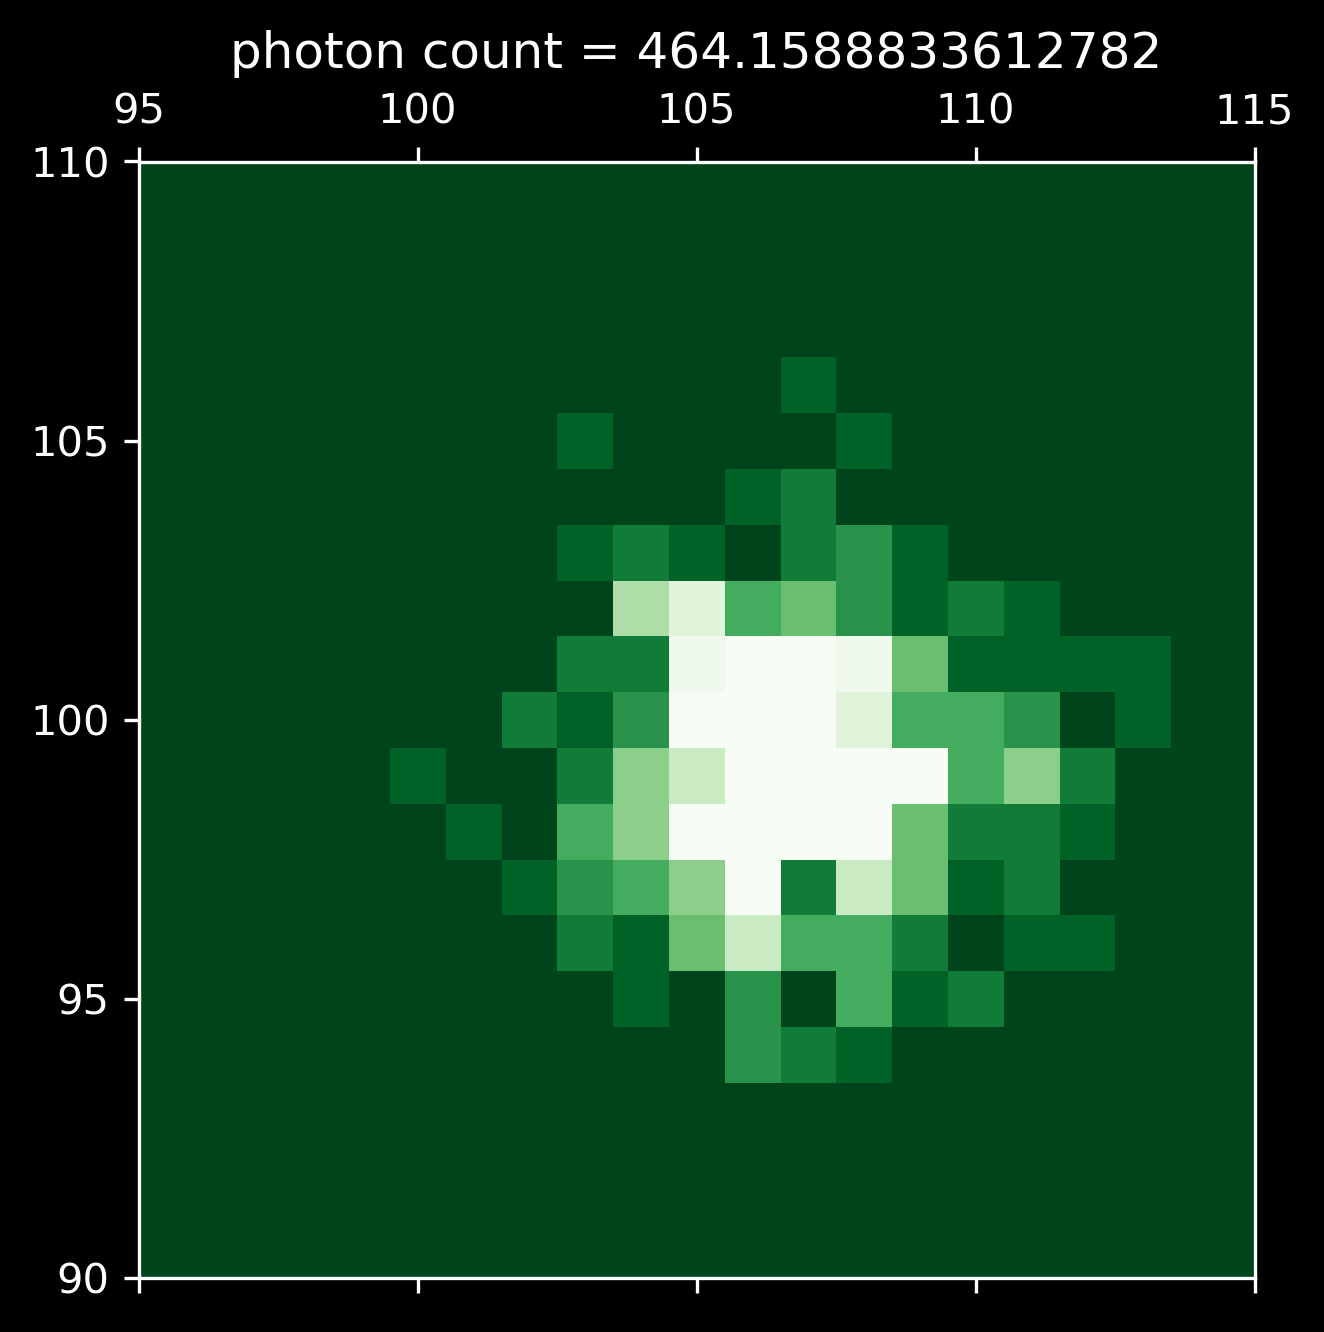

In [3]:
# using "photon sampling" with increasing photon count
image = np.zeros([512,512],dtype=np.uint16);

n_spots = 10
spot_y = np.linspace(10,300,n_spots)
photon_count = np.logspace(1,6,n_spots)
for i in range(n_spots):
    spots_xy = np.array( [[100]*1, [spot_y[i]],]).T
                        
    values_xy = [100]
    sigma = [2]
    spot_size = 20
    intensity_scale = 10
    if i == 0:
        frame = rsp.Frame2D().make(spots_xy, values_xy, spot_size, sigma,
                 image, intensity_scale, poisson_sample_spot=True, photon_count=photon_count[i])
    else:
        frame = rsp.Frame2D().make(spots_xy, values_xy, spot_size, sigma,
                 frame, intensity_scale, poisson_sample_spot=True, photon_count=photon_count[i])        

plt.figure(dpi=300)
plt.matshow(frame, vmax=500, cmap='Greens_r')
plt.xlim([0,310])
plt.ylim([90,110])

plt.figure(dpi=300)
plt.matshow(frame, vmax=500, cmap='Greens_r')
plt.xlim([290,310])
plt.ylim([90,110])
plt.title('photon count = %s'%str(photon_count[-1]))


plt.figure(dpi=300)
plt.matshow(frame, vmax=500, cmap='Greens_r')
plt.xlim([95,115])
plt.ylim([90,110])
plt.title('photon count = %s'%str(photon_count[3]))

Text(0.5, 1.0, 'intensity_value = 1667.3333333333335')

<Figure size 1920x1440 with 0 Axes>

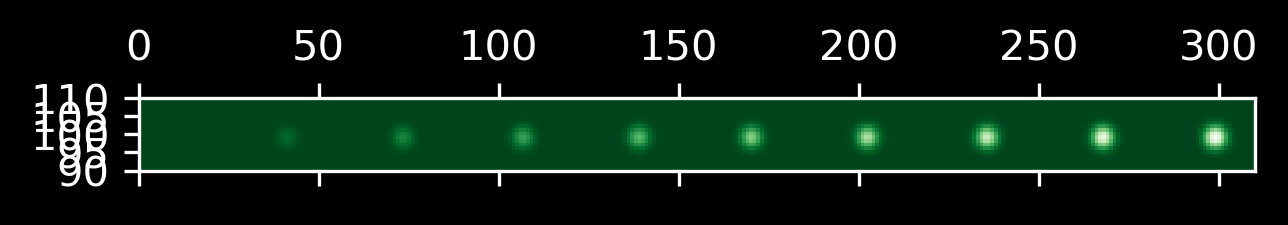

<Figure size 1920x1440 with 0 Axes>

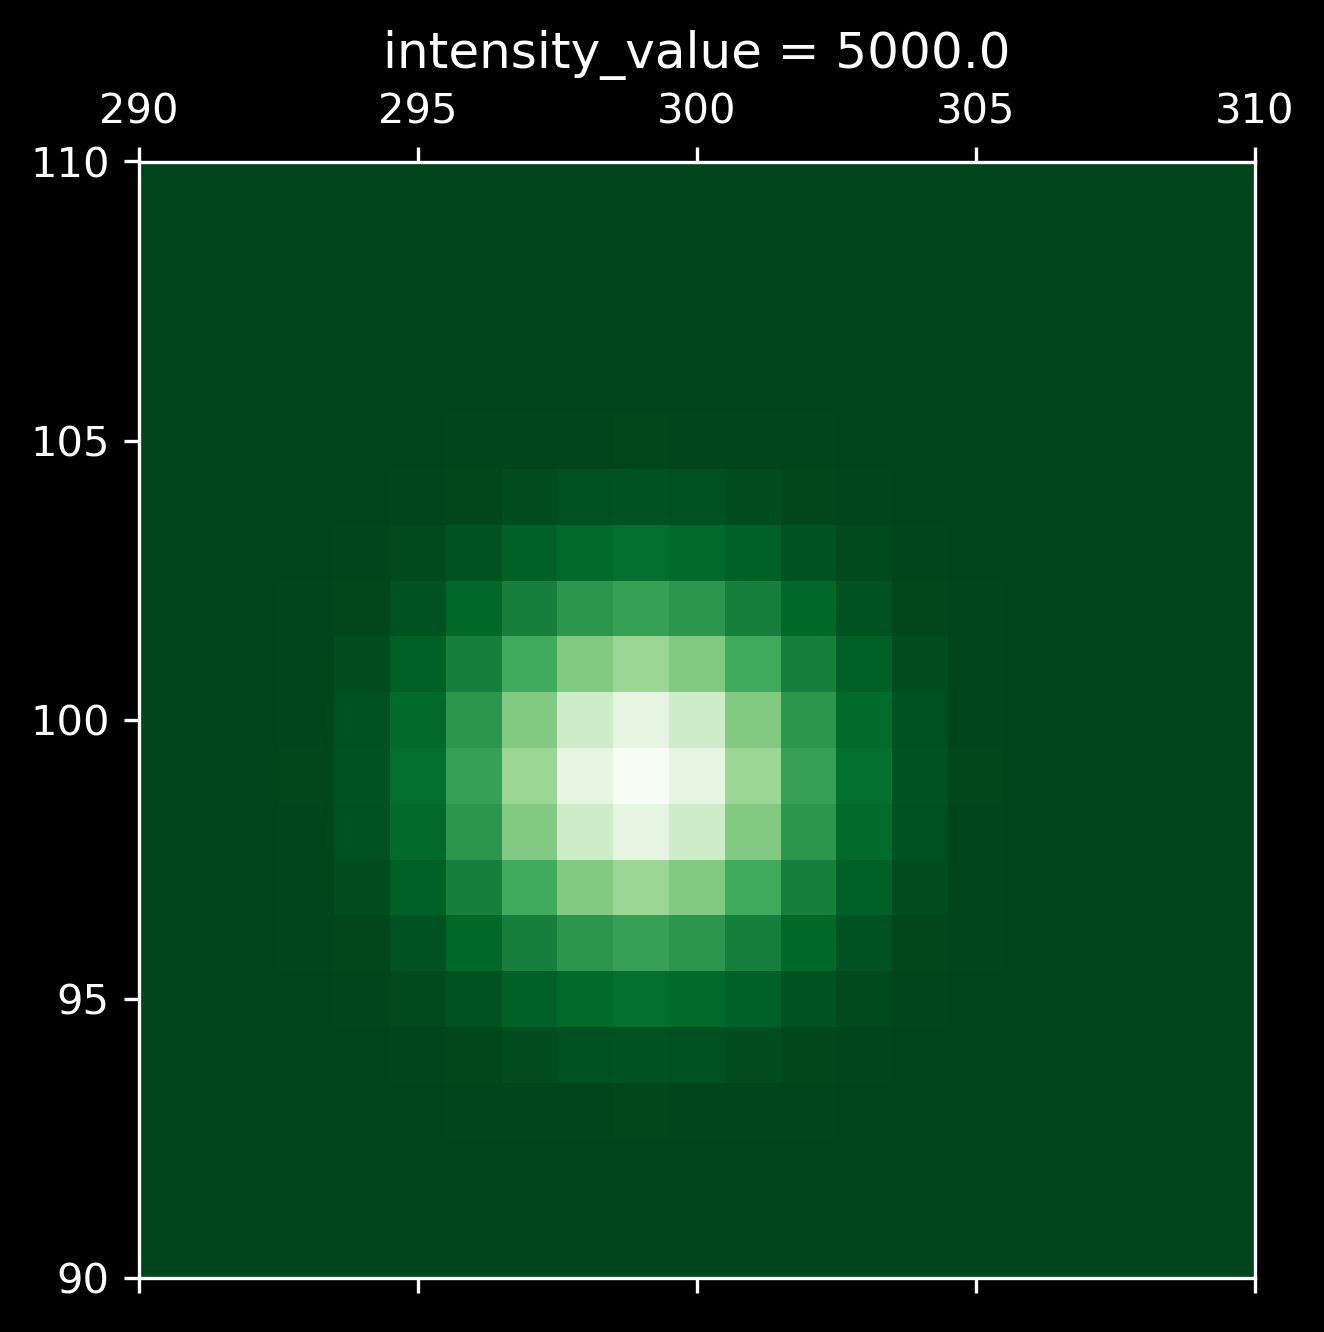

<Figure size 1920x1440 with 0 Axes>

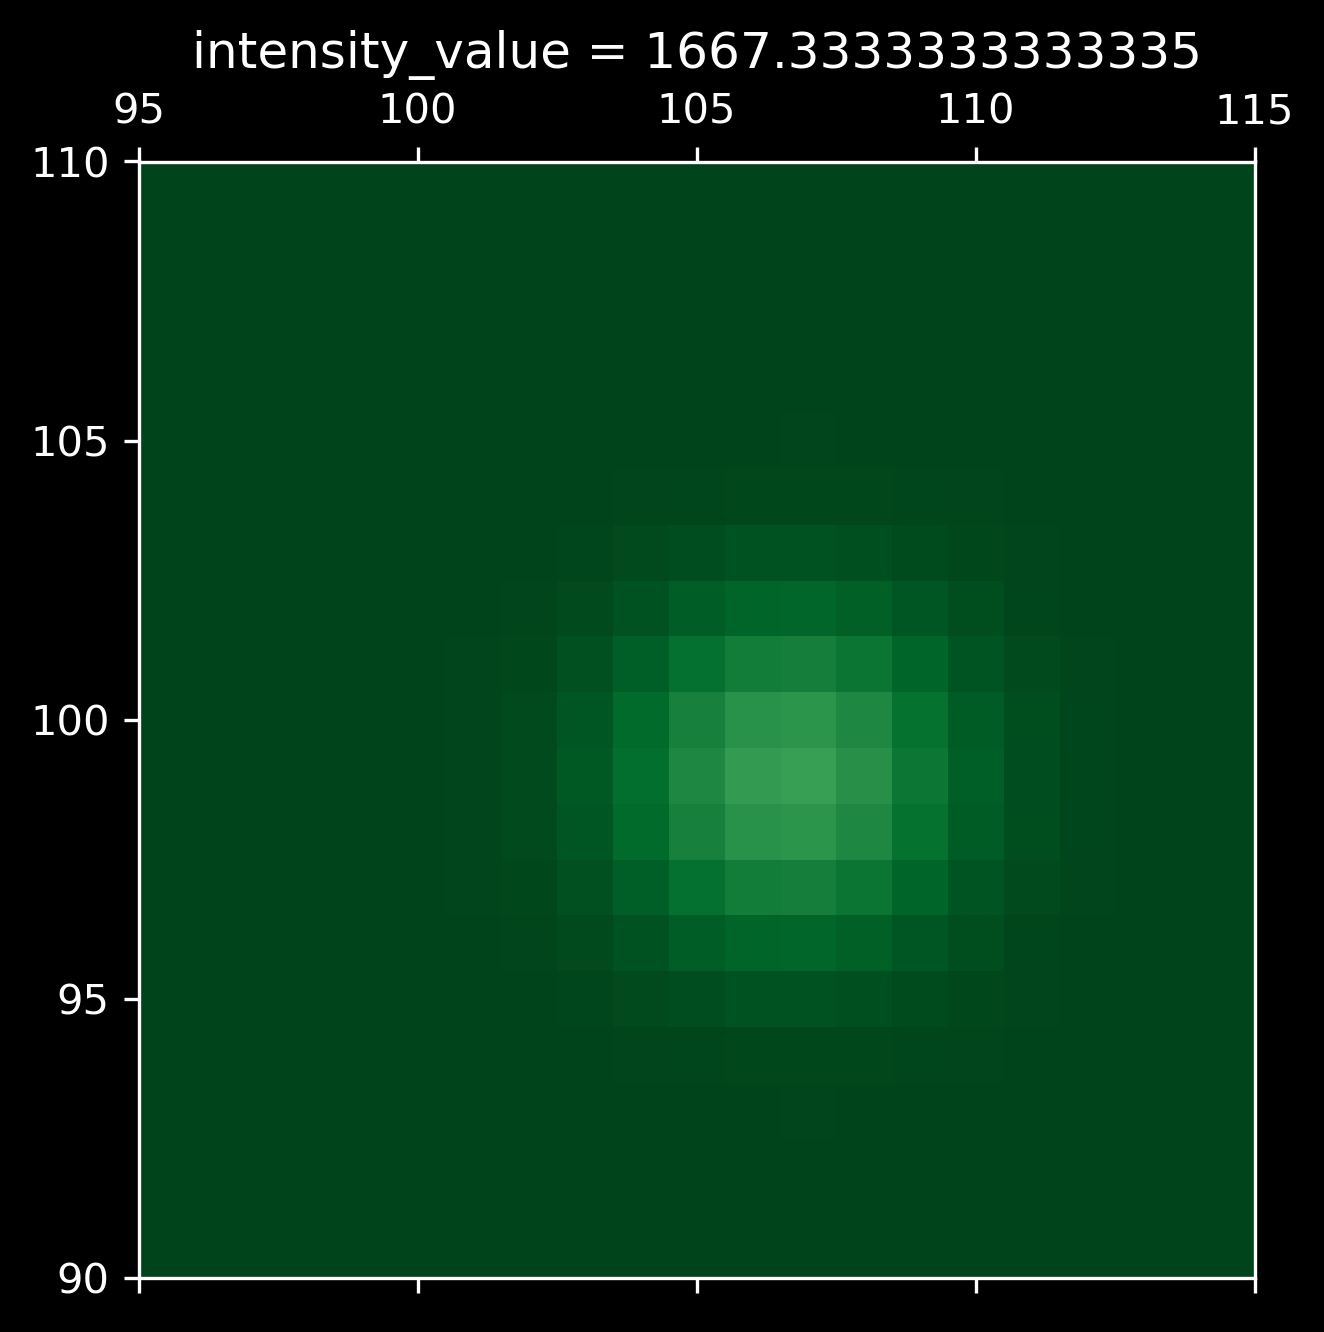

In [4]:

image = np.zeros([512,512],dtype=np.uint16);

n_spots = 10
spot_y = np.linspace(10,300,n_spots)
values = np.linspace(1,5000,n_spots)
for i in range(n_spots):
    spots_xy = np.array( [[100]*1, [spot_y[i]],]).T
                        
    values_xy = [values[i]]
    sigma = [2]
    spot_size = 20
    intensity_scale = 100
    if i == 0:
        frame = rsp.Frame2D().make(spots_xy, values_xy, spot_size, sigma,
                 image, intensity_scale, poisson_sample_spot=False)
    else:
        frame = rsp.Frame2D().make(spots_xy, values_xy, spot_size, sigma,
                 frame, intensity_scale, poisson_sample_spot=False)        

plt.figure(dpi=300)
plt.matshow(frame, cmap='Greens_r')
plt.xlim([0,310])
plt.ylim([90,110])

plt.figure(dpi=300)
plt.matshow(frame, cmap='Greens_r')
plt.xlim([290,310])
plt.ylim([90,110])
plt.title('intensity_value = %s'%str(values[-1]))


plt.figure(dpi=300)
plt.matshow(frame, cmap='Greens_r')
plt.xlim([95,115])
plt.ylim([90,110])
plt.title('intensity_value = %s'%str(values[3]))

In [6]:
spots_xy.shape

(1, 2)

# Base Image Generation methods

generating background video of 1 new frames via Gaussian...: 100%|█████████| 262144/262144 [00:01<00:00, 139424.55it/s]


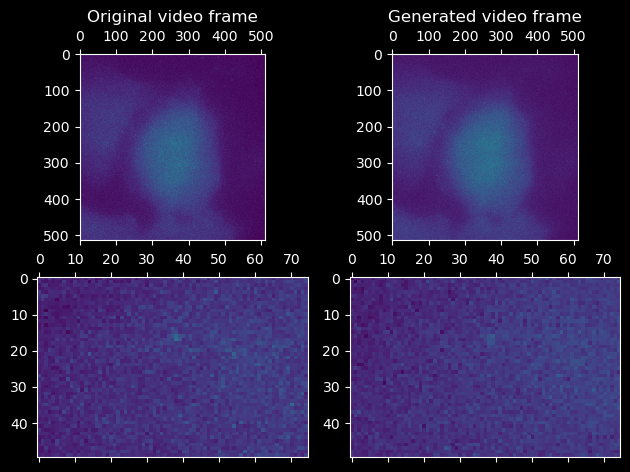

In [5]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))

bg_maker = rsp.BackgroundGen2D(base_image[:,:,:,0])
bg_frame = bg_maker.make([1],1, method='gaussian', verbose=1)

f,ax = plt.subplots(2,2,tight_layout=True)
ax[0,1].matshow(bg_frame[0], vmax=5000)
ax[0,1].set_title('Generated video frame')
ax[0,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,0].set_title('Original video frame')
ax[1,1].matshow(bg_frame[0][225:275,200:275], vmax=5000)
ax[1,0].matshow(base_image[1, 225:275,200:275, 0], vmax=5000)
plt.show()

In [64]:
np.moveaxis(np.array([trajs]*3),0,-1).shape

(2, 1001, 5, 3)

generating background video of 1 new frames via Poisson...: 100%|██████████| 262144/262144 [00:01<00:00, 174808.79it/s]


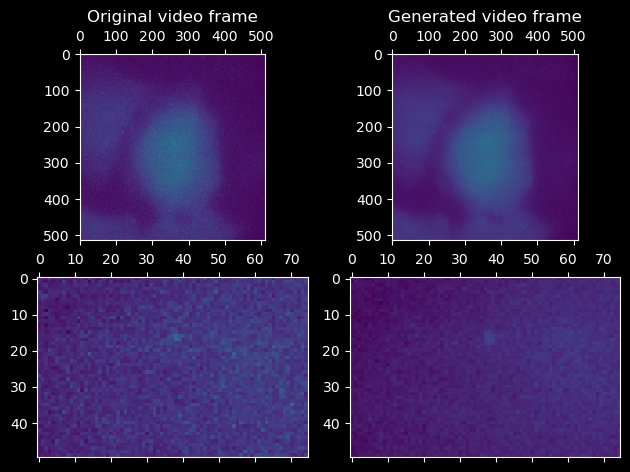

In [6]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))

bg_maker = rsp.BackgroundGen2D(base_image[:,:,:,0])
bg_frame = bg_maker.make([1],1, method='possion', verbose=1)


f,ax = plt.subplots(2,2,tight_layout=True)
ax[0,1].matshow(bg_frame[0], vmax=5000)
ax[0,1].set_title('Generated video frame')
ax[0,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,0].set_title('Original video frame')
ax[1,1].matshow(bg_frame[0][225:275,200:275], vmax=5000)
ax[1,0].matshow(base_image[1, 225:275,200:275, 0], vmax=5000)
plt.show()


generating background video of 1 new frames via Correlated Gaussian...: 100%|█| 262144/262144 [00:07<00:00, 33934.66it/


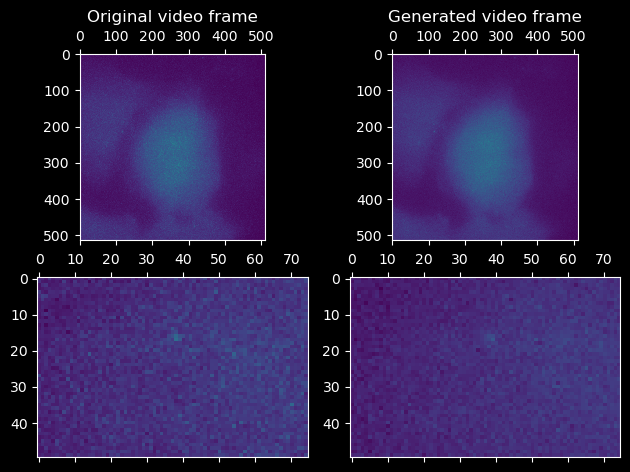

In [7]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))

bg_maker = rsp.BackgroundGen2D(base_image[:,:,:,0])
bg_frame = bg_maker.make([.4, 5, 1],1, method='gaussian_w_tau_correlation', verbose=1)


f,ax = plt.subplots(2,2,tight_layout=True)
ax[0,1].matshow(bg_frame[0], vmax=5000)
ax[0,1].set_title('Generated video frame')
ax[0,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,0].set_title('Original video frame')
ax[1,1].matshow(bg_frame[0][225:275,200:275], vmax=5000)
ax[1,0].matshow(base_image[1, 225:275,200:275, 0], vmax=5000)
plt.show()


generating background video of 1 new frames via Correlated Gaussian...: 100%|█| 262144/262144 [00:07<00:00, 34837.45it/
generating background video of 1 new frames via Correlated Gaussian (subsequent)...: 100%|█| 262144/262144 [00:03<00:00


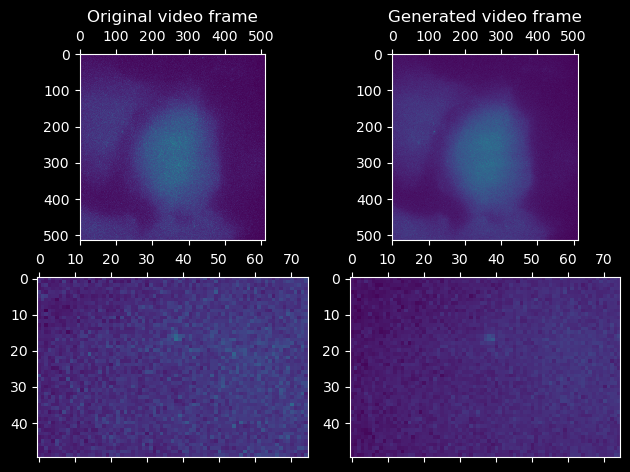

In [8]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))

bg_maker = rsp.BackgroundGen2D(base_image[:,:,:,0])
bg_frame = bg_maker.make([.4, 5, 1],1, method='gaussian_w_tau_correlation', verbose=1)

bg_frame2 = bg_maker.make([.4, 1, bg_frame[0]],1, method='gaussian_w_tau_correlation2', verbose=1)

f,ax = plt.subplots(2,2,tight_layout=True)
ax[0,1].matshow(bg_frame2[0], vmax=5000)
ax[0,1].set_title('Generated video frame')
ax[0,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,0].set_title('Original video frame')
ax[1,1].matshow(bg_frame2[0][225:275,200:275], vmax=5000)
ax[1,0].matshow(base_image[1, 225:275,200:275, 0], vmax=5000)
plt.show()

## Diffusion

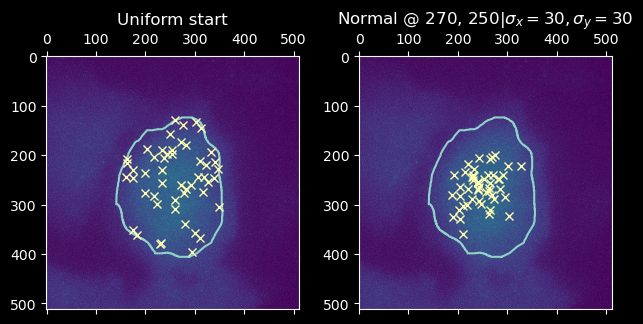

In [25]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(0)+'.tif'))

vertices = rsp.Utilities.mask_to_vertices(mask_image)
vertices = approximate_polygon(vertices, tolerance=.5)

f,ax = plt.subplots(1,2, tight_layout=True)
ax[0].matshow(base_image[1,:,:,0], vmax=5000)
ax[1].matshow(base_image[1,:,:,0], vmax=5000)
ax[0].plot(vertices.T[1], vertices.T[0])
ax[1].plot(vertices.T[1], vertices.T[0])
ax[0].set_title('Uniform start')

diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(50)
ax[0].plot(spots[1], spots[0],'x')

spots = diff.initialize_spots(50, parameters=[(270,250),(30,30)], start='gaussian_point')
ax[1].plot(spots[1], spots[0],'x')
ax[1].set_title(r'Normal @ %i, %i|$\sigma_x = %i, \sigma_y = %i$'%(270,250,30,30))

plt.show()


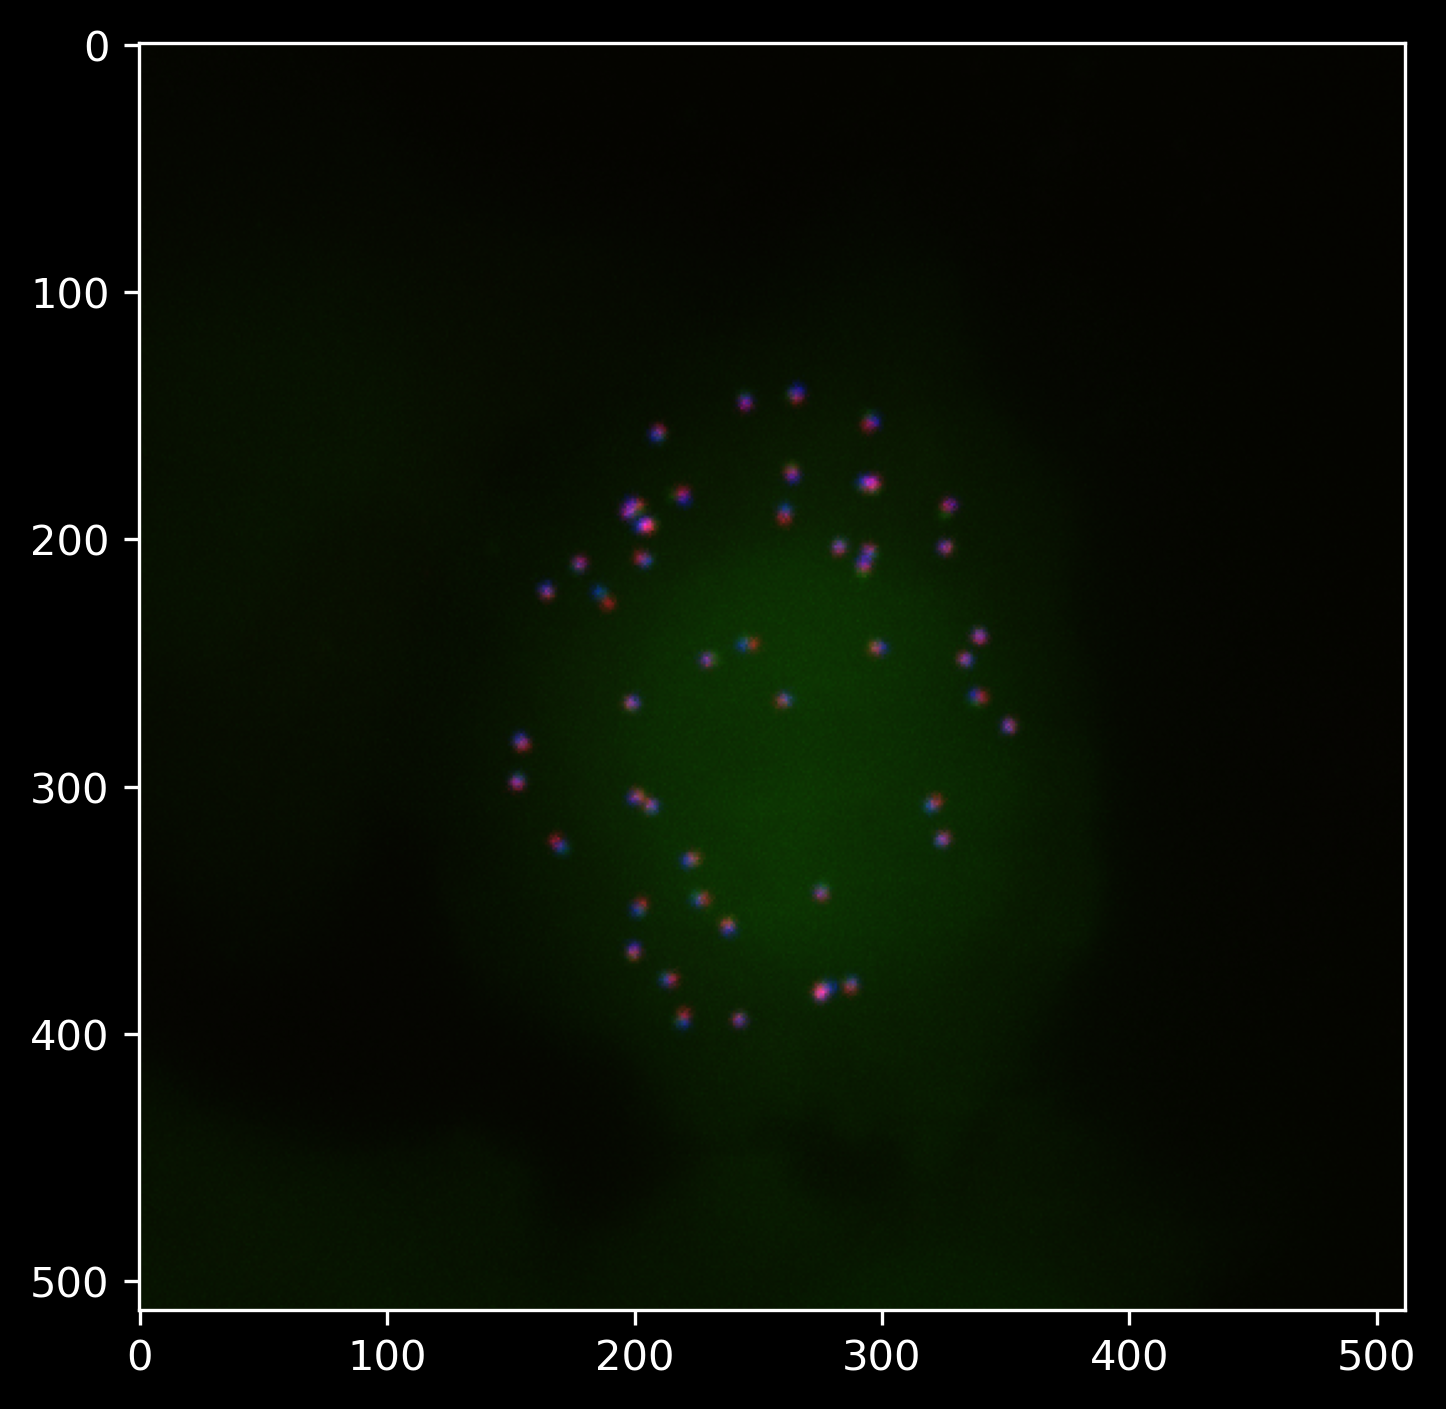

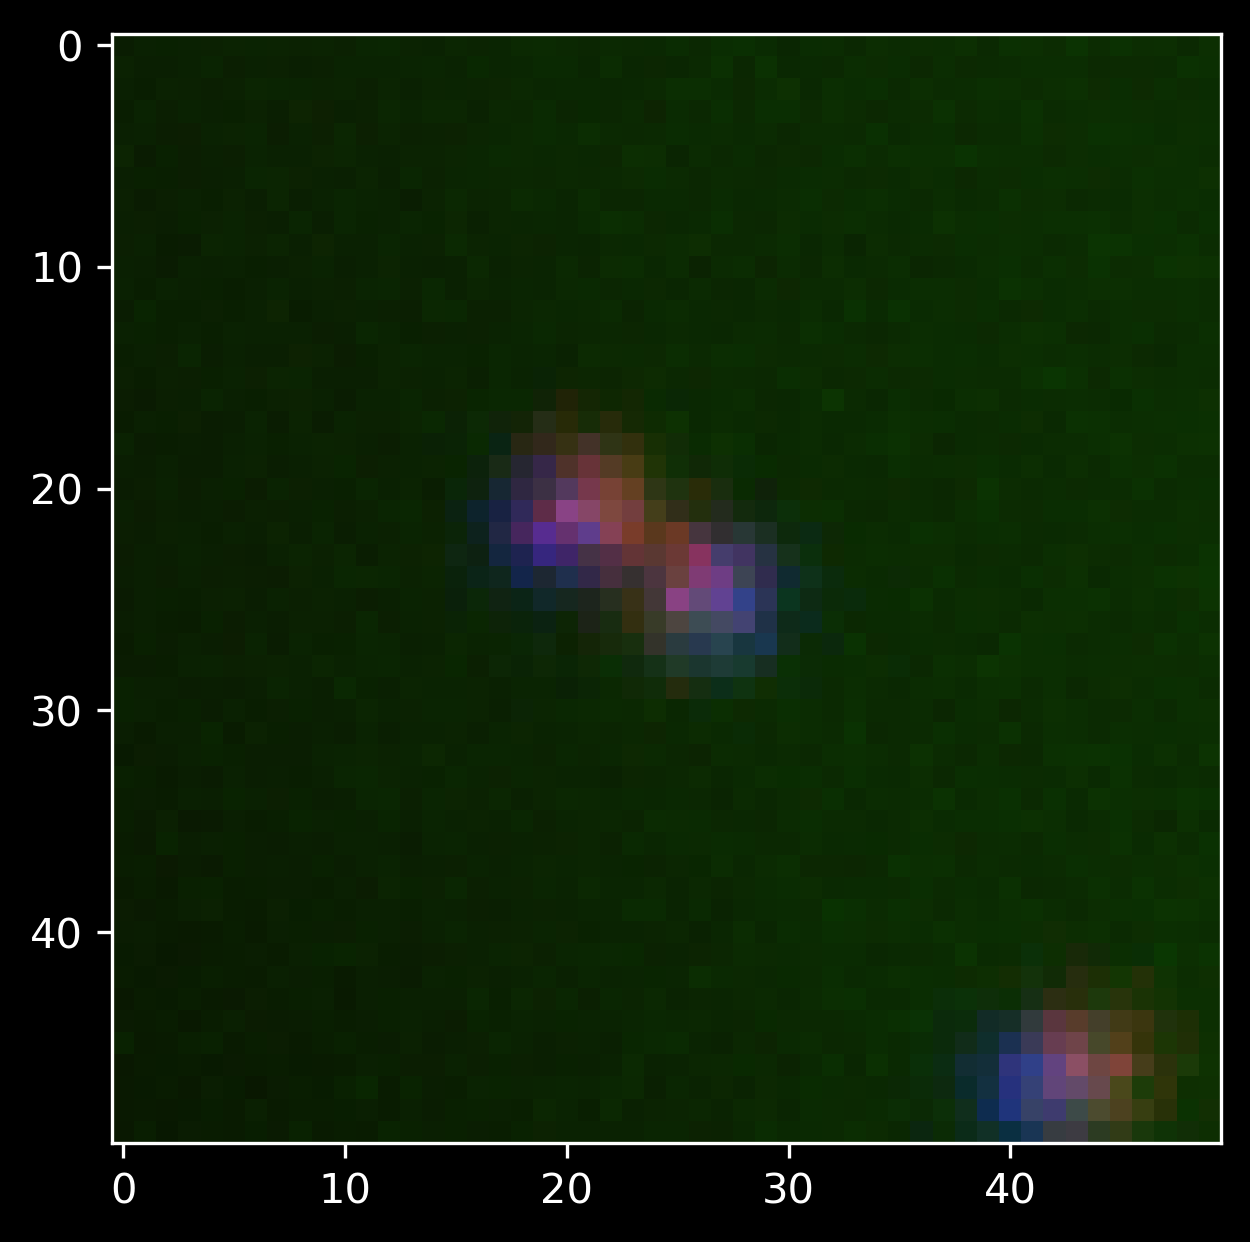

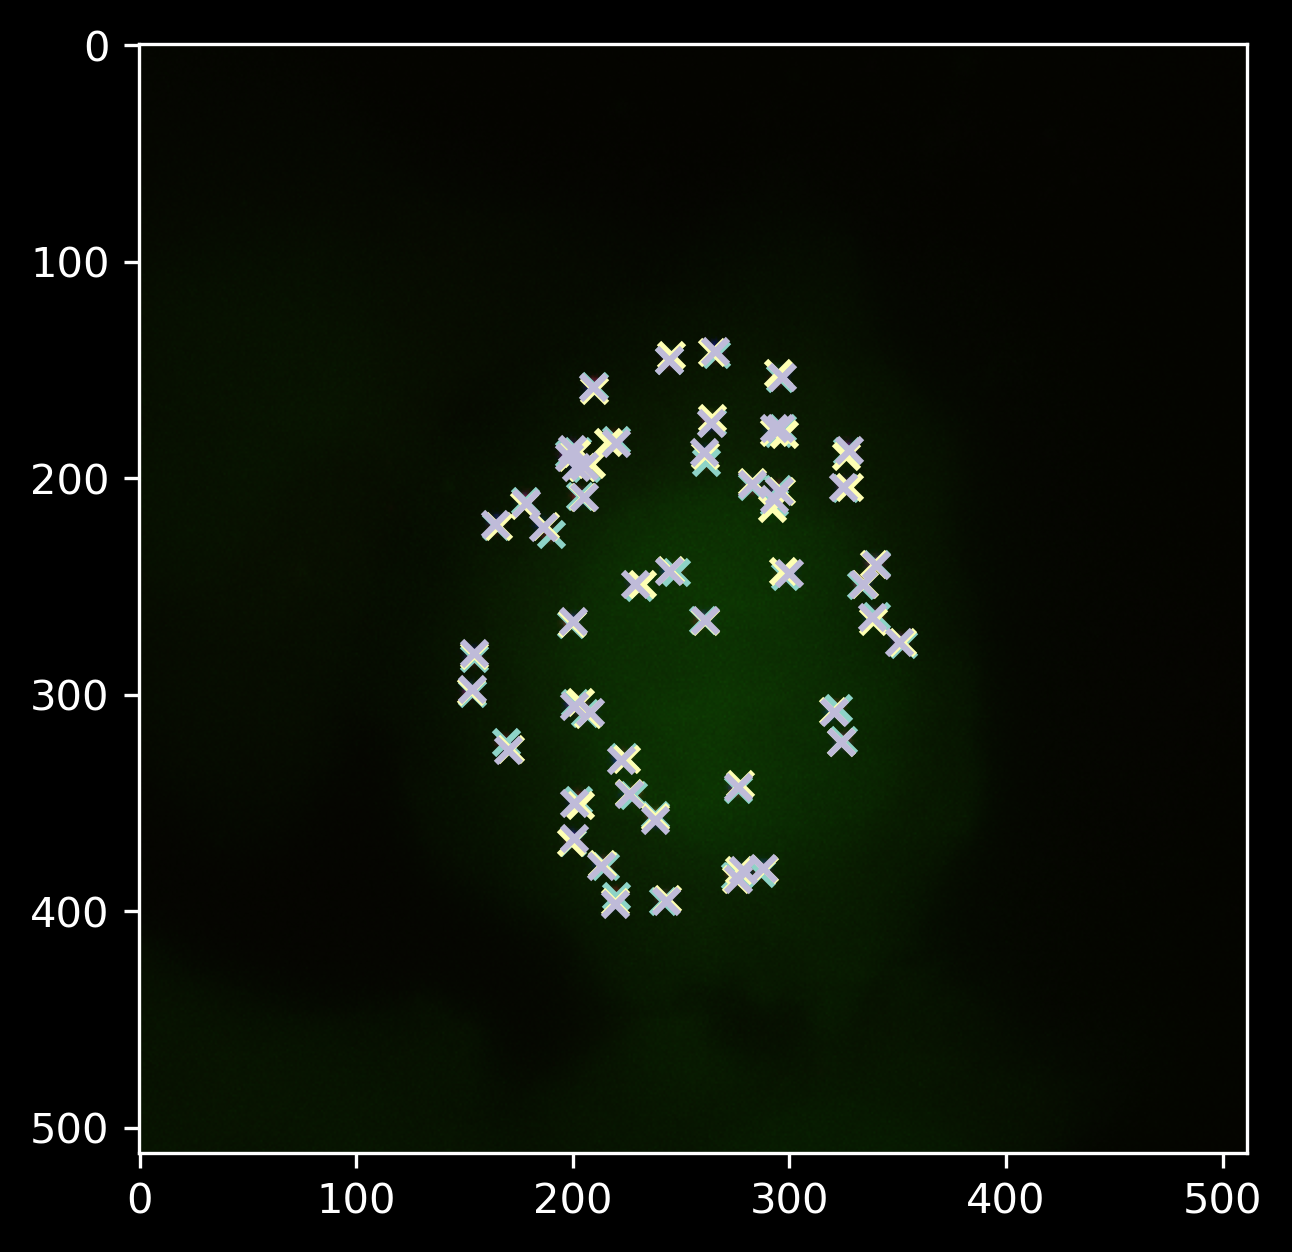

In [20]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(0)+'.tif'))


vertices = rsp.Utilities.mask_to_vertices(mask_image)
vertices = approximate_polygon(vertices, tolerance=.5)

f,ax = plt.subplots(1,1, tight_layout=True)

diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(50)

#this uses gaussian: another example would be registration error.
spots_3 = diff.jitter(spots, 3, parameters=[1], method='gaussian')

n = 50
values_xy = [100]
sigma = [2]
spot_size = [20]
intensity_scale = 200
frame1 = rsp.Frame2D().make(spots_3[:,:,0].T, values_xy*n, spot_size*n, sigma*n,
         base_image[0,:,:,0], intensity_scale, poisson_sample_spot=True, photon_count=1000)

values_xy = [50]
sigma = [2]
spot_size = 20
spot_size = [20]
intensity_scale = 100
frame2 = rsp.Frame2D().make(spots_3[:,:,1].T, values_xy*n, spot_size*n, sigma*n,
         base_image[0,:,:,1], intensity_scale, poisson_sample_spot=True, photon_count=1000)


values_xy = [200]
sigma = [2]
spot_size = [20]
intensity_scale = 100
frame3 = rsp.Frame2D().make(spots_3[:,:,2].T, values_xy*n, spot_size*n, sigma*n,
         base_image[0,:,:,0]*.2, intensity_scale, poisson_sample_spot=True, photon_count=1000)

new_image = np.moveaxis(np.array([frame1,frame2,frame3]),0,-1)/np.max(np.moveaxis(np.array([frame1,frame2,frame3]),0,-1))

plt.imshow(new_image)
plt.figure()
plt.imshow(new_image[int(spots_3[0,0,0]-25):int(spots_3[0,0,0]+25),int(spots_3[1,0,0]-25):int(spots_3[1,0,0]+25)])
#ax[0].plot(spots[1], spots[0],'x')
#ax[0].matshow(base_image[1,:,:,0], vmax=5000)

#ax[0].plot(vertices.T[1], vertices.T[0])
#ax[0].set_title('Uniform start')
plt.figure()
plt.imshow(new_image)
plt.scatter(spots_3[1,:,0],spots_3[0,:,0],marker='x')
plt.scatter(spots_3[1,:,1],spots_3[0,:,1],marker='x')
plt.scatter(spots_3[1,:,2],spots_3[0,:,2],marker='x')


#plt.show()

In [12]:
frame2

52428

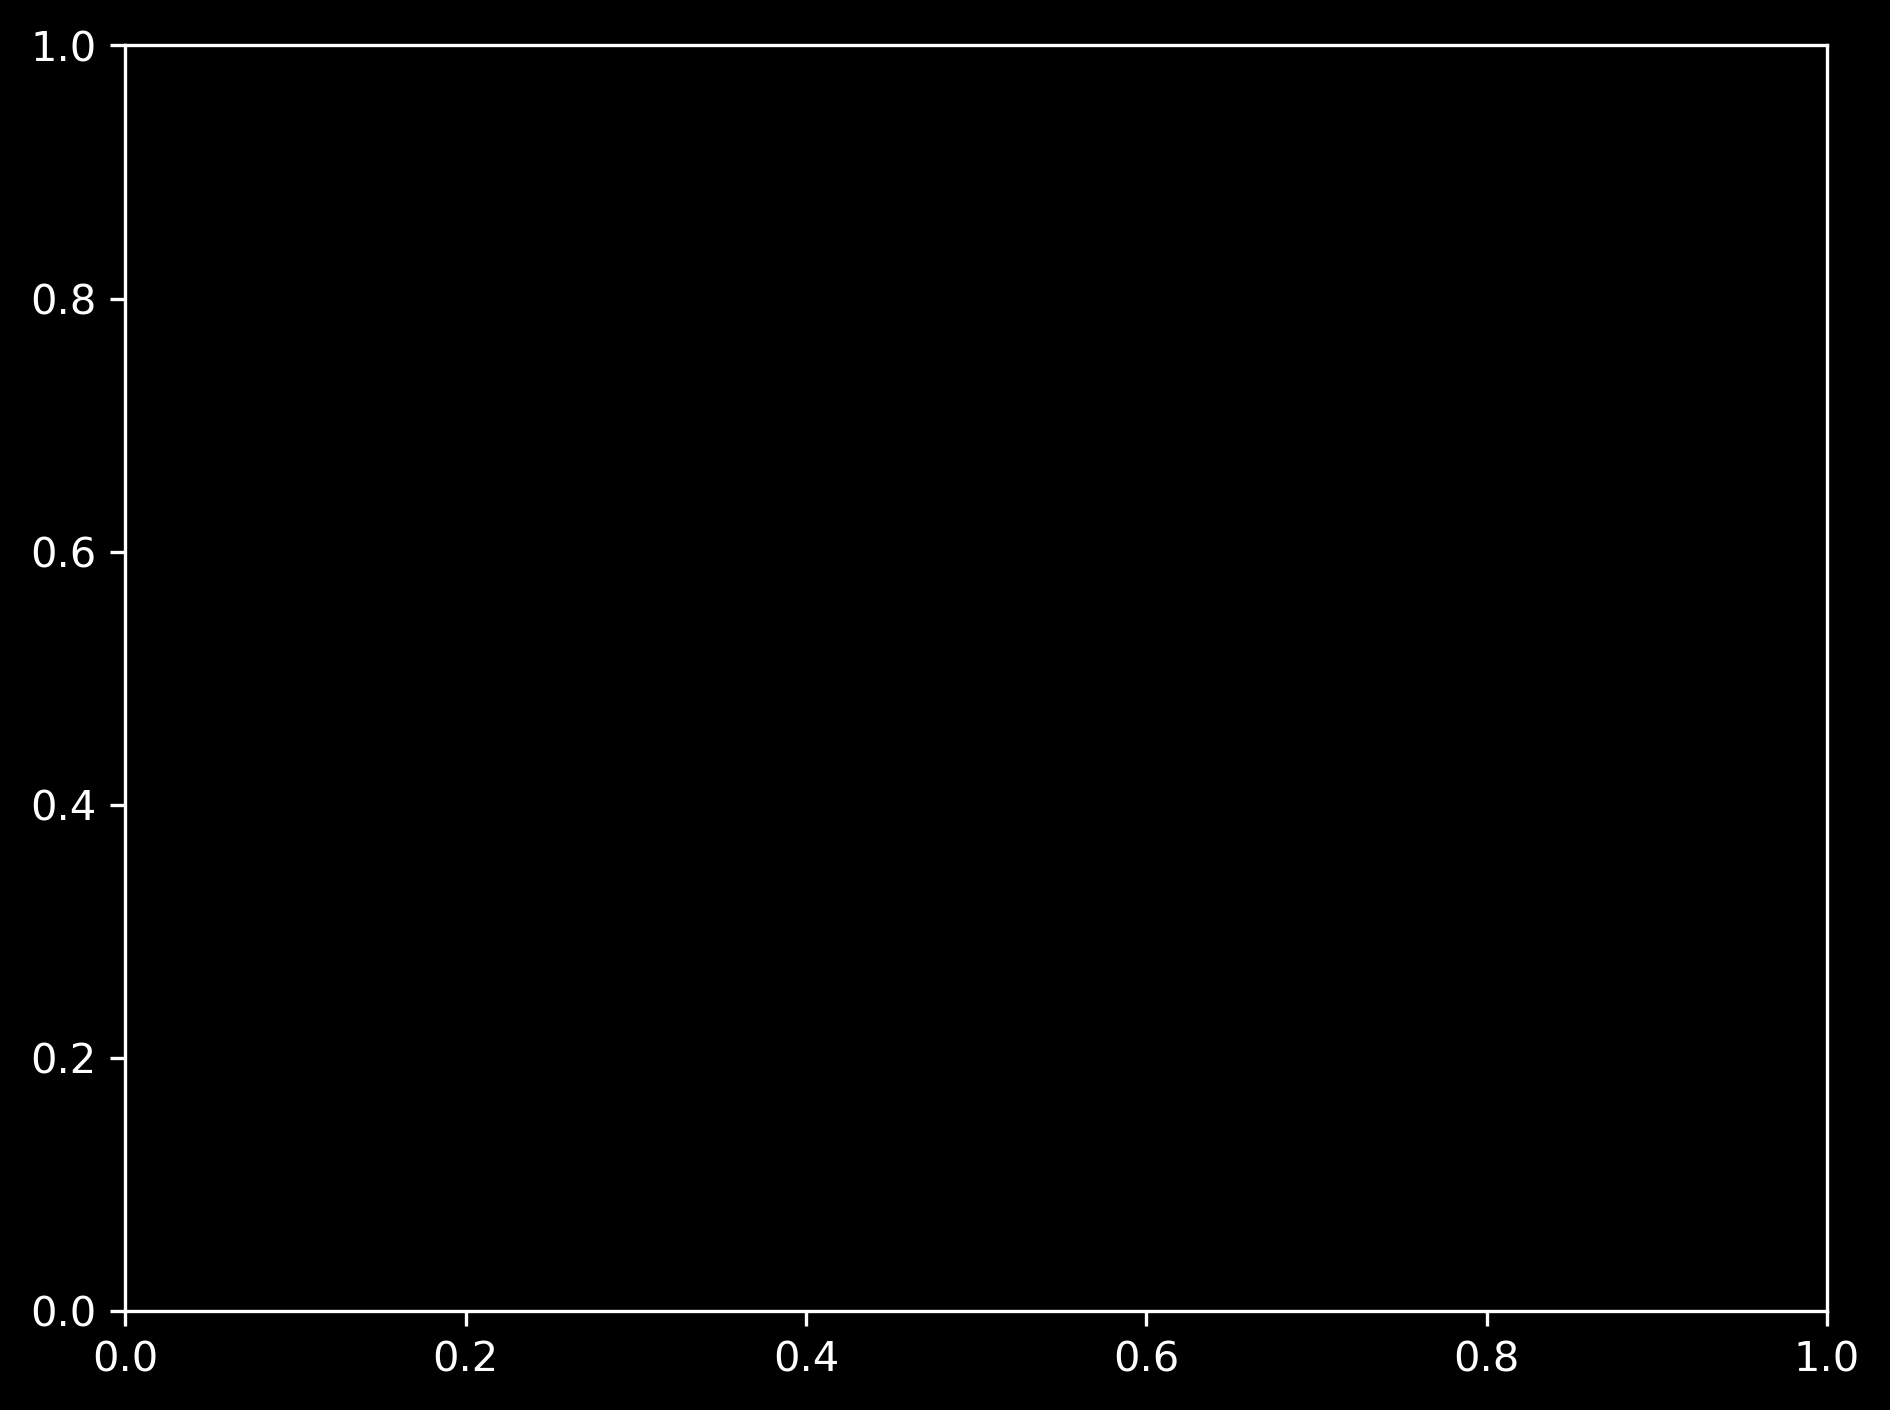

In [7]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(0)+'.tif'))

vertices = rsp.Utilities.mask_to_vertices(mask_image)
vertices = approximate_polygon(vertices, tolerance=.5)

f,ax = plt.subplots(1,1, tight_layout=True)

diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(50)
spots_3 = diff.jitter(spots, 3, parameters=[.5], method='gaussian')

n = 50
values_xy = [100]
sigma = [2]
spot_size = [20]
intensity_scale = 10
frame1 = rsp.Frame2D().make(spots_3[:,:,0].T, values_xy*n, spot_size*n, sigma*n,
         base_image[0,:,:,0], intensity_scale, poisson_sample_spot=True, photon_count=1000)



[(298.3034025137403, 354.5499999999997), (298.4500000000165, 354.76123057533994), (298.7892140030479, 355.25)]
[(226.615732606924, 350.0842673930769), (228.51033278293724, 349.64999999999935)]
[(400.65000000000356, 256.13068962547516), (400.54370474931005, 255.85000000000582), (399.2855037904059, 252.52751895201843)]
[(137.49943273696212, 313.2499999999995), (138.14999999999435, 313.5743759691272), (139.66092822759344, 314.3277320568983), (140.9499999999921, 314.9704694481068), (141.71118509347178, 315.3500000000013), (142.98525976404306, 315.9852597640438), (146.5144230810167, 317.7449175830027)]


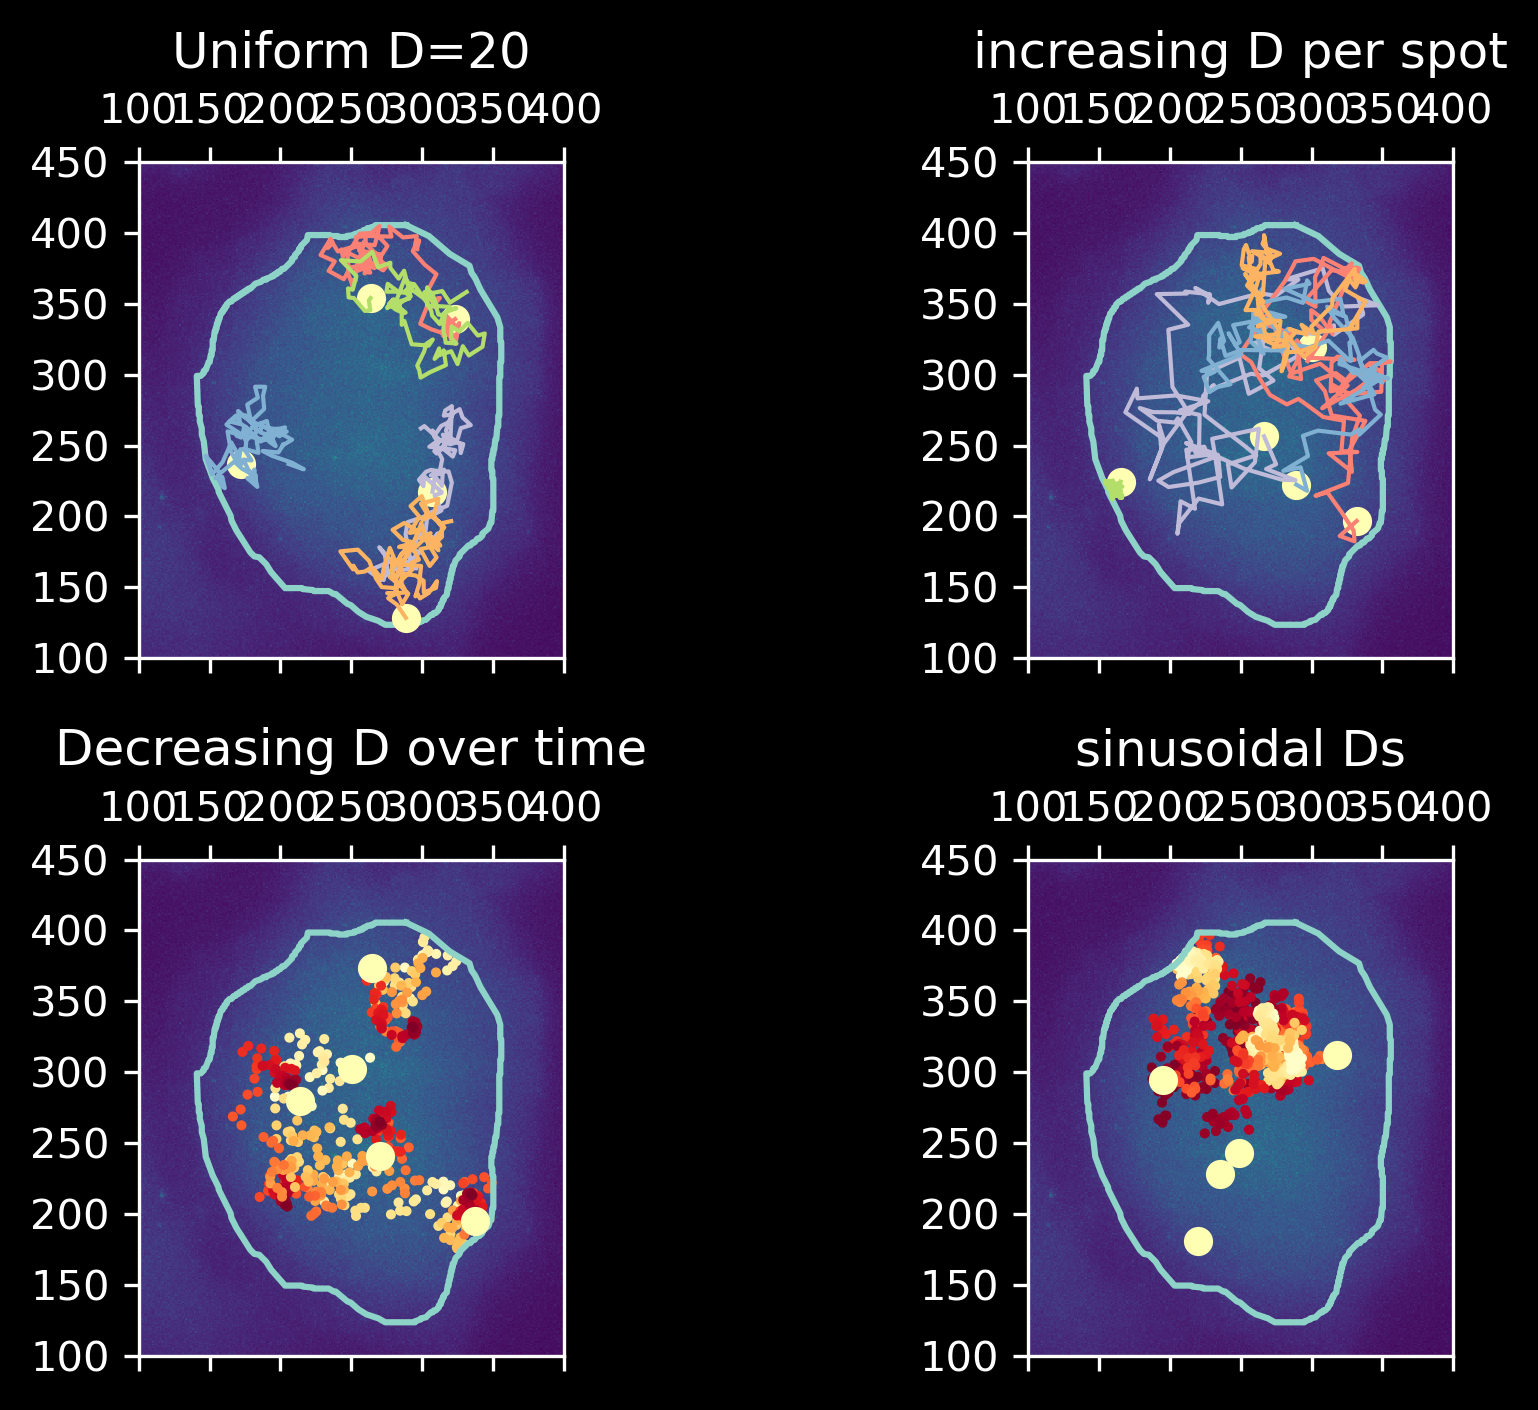

In [8]:
base_image = imread(video_dir.joinpath('cell_shape_'+str(0)+'.tif'))
mask_image = imread(masks_dir.joinpath('mask_cell_shape_'+str(0)+'.tif'))

vertices = rsp.Utilities.mask_to_vertices(mask_image)
vertices = approximate_polygon(vertices, tolerance=.5)

f,ax = plt.subplots(2,2, tight_layout=True, dpi=300)
ax[0,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[1,0].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,1].matshow(base_image[1,:,:,0], vmax=5000)
ax[1,1].matshow(base_image[1,:,:,0], vmax=5000)
ax[0,0].plot(vertices.T[1], vertices.T[0])
ax[1,0].plot(vertices.T[1], vertices.T[0])
ax[0,1].plot(vertices.T[1], vertices.T[0])
ax[1,1].plot(vertices.T[1], vertices.T[0])

D = 20
diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(5,)
trajs = diff.gen(spots, D, np.linspace(0,100,101), 1)
ax[0,0].plot(spots[1], spots[0],'o')
ax[0,0].plot(trajs[1], trajs[0], lw=1)
ax[0,0].set_title('Uniform D=%i'%D)
ax[0,0].set_xlim([100,400])
ax[0,0].set_ylim([100,450])

D = np.linspace(0,1,101)[::-1]*50
diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(5,)
trajs = diff.gen(spots, D, np.linspace(0,100,101), 1)
ax[1,0].plot(spots[1], spots[0],'o')
for i in range(5):
    ax[1,0].scatter(trajs[1,:,i], trajs[0,:,i], c=np.linspace(0,1,101), cmap='YlOrRd', s=2)
ax[1,0].set_title('Decreasing D over time')
ax[1,0].set_xlim([100,400])
ax[1,0].set_ylim([100,450])

D = np.linspace(1,100,5)[::-1]
diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(5,)
trajs = diff.gen(spots, D, np.linspace(0,100,101), 1)
ax[0,1].plot(spots[1], spots[0],'o')
ax[0,1].plot(trajs[1], trajs[0], lw=1)
ax[0,1].set_title('increasing D per spot')
ax[0,1].set_xlim([100,400])
ax[0,1].set_ylim([100,450])

a = np.random.randint(1,25,size=(5,1))
D = np.vstack([np.sin(np.linspace(0,20,1001))]*5)*a + a+1
D = D.T
diff = rsp.Diffusion2D(vertices)
spots = diff.initialize_spots(5,)
trajs = diff.gen(spots, D, np.linspace(0,1000,1001), 1)
ax[1,1].plot(spots[1], spots[0],'o')
for i in range(1):
    ax[1,1].scatter(trajs[1,:,i], trajs[0,:,i], c=D[:,i]/np.max(D[:,i]), cmap='YlOrRd', s=2)
ax[1,1].set_title('sinusoidal Ds')
ax[1,1].set_xlim([100,400])
ax[1,1].set_ylim([100,450])

plt.show()

In [7]:
rsp.Banner().print_banner()

 
  ██████╗░░██████╗███╗░░██╗░█████╗░██████╗░███████╗██████╗░ 
  ██╔══██╗██╔════╝████╗░██║██╔══██╗██╔══██╗██╔════╝██╔══██╗ 
  ██████╔╝╚█████╗░██╔██╗██║███████║██████╔╝█████╗░░██║░░██║ 
  ██╔══██╗░╚═══██╗██║╚████║██╔══██║██╔═══╝░██╔══╝░░██║░░██║ 
  ██║░░██║██████╔╝██║░╚███║██║░░██║██║░░░░░███████╗██████╔╝ 
             by : L. Aguilera, T. Stasevich, and B. Munsky 


In [6]:
# These are the parameters that need to be tested. 
number_of_simulated_cells = 8     # PLEASE TEST MIN 1 MAX 10
number_spots_per_cell = 40           # PLEASE TEST MIN 5 MAX 200
simulation_time_in_sec = 40          # PLEASE TEST MIN 10 MAX 100
min_percentage_time_tracking = 0.3   # (normalized) minimum time to consider a trajectory.
average_cell_diameter = 400
diffusion_coefficient = 0.1          # PLEASE TEST MIN 0.1 MAX 0.1
microns_per_pixel = 0.13
spot_size = 7 # spot size for the simulation and tracking.
spot_sigma = 1.5
elongation_rate = 10
initiation_rate = 0.01
simulated_RNA_intensities_method = 'random'
frame_selection_empty_video = 'gaussian' # Options are: 'constant' , 'shuffle' and 'loop' 'linear_interpolation', 'gaussian', 'poisson'
dataframe_format = 'long' # 'short'  'long'
store_videos_in_memory = False
save_as_gif = False 
show_plot = False  # Flag to show plots for the detection and tracking process.
select_background_cell_index = None # Integer in range 0 to 8, or use None to select a random value. 
perform_video_augmentation = True 
basal_intensity_in_background_video = 10000
scale_intensity_in_base_video=False

# Parameters for pipeline tracking
intensity_calculation_method = 'disk_donut'  # options are : 'total_intensity' and 'disk_donut' 'gaussian_fit'
mask_selection_method = 'max_area' # options are : 'max_spots' and 'max_area' 
use_optimization_for_tracking = 1 # 0 not using, 1 is using optimization
selected_channel_tracking = 0
selected_channel_segmentation = 1
intensity_scale_ch0 = 1
intensity_scale_ch1 = 1
intensity_scale_ch2 = None
particle_detection_size = spot_size


## Running the simulations

In [7]:
list_videos, list_masks, list_dataframe_simulated_cell, merged_dataframe_simulated_cells, ssa_trajectories, list_files_names, video_path, dataframe_path = rsp.simulate_cell( video_dir, 
                                                                        list_gene_sequences = gene_file,
                                                                        list_number_spots= number_spots_per_cell,
                                                                        list_target_channels_proteins = 1,
                                                                        list_target_channels_mRNA = 0, 
                                                                        list_diffusion_coefficients=diffusion_coefficient,
                                                                        list_elongation_rates=elongation_rate,
                                                                        list_initiation_rates=initiation_rate,
                                                                        masks_dir=masks_dir, 
                                                                        list_label_names=1,
                                                                        number_cells = number_of_simulated_cells,
                                                                        simulation_time_in_sec = simulation_time_in_sec,
                                                                        step_size_in_sec = 1,
                                                                        save_as_gif = save_as_gif,
                                                                        frame_selection_empty_video=frame_selection_empty_video,
                                                                        spot_size = spot_size,
                                                                        spot_sigma = spot_sigma,
                                                                        intensity_scale_ch0 = intensity_scale_ch0,
                                                                        intensity_scale_ch1 = intensity_scale_ch1,
                                                                        intensity_scale_ch2 = intensity_scale_ch2,
                                                                        dataframe_format = 'long',
                                                                        simulated_RNA_intensities_method=simulated_RNA_intensities_method,
                                                                        store_videos_in_memory= store_videos_in_memory,
                                                                        scale_intensity_in_base_video=scale_intensity_in_base_video,
                                                                        basal_intensity_in_background_video=basal_intensity_in_background_video,
                                                                        microns_per_pixel=microns_per_pixel,
                                                                        select_background_cell_index=select_background_cell_index,
                                                                        perform_video_augmentation=perform_video_augmentation)

C:\Users\willi\Documents\GitHub\rsnaped\notebooks_final\temp_simulation\1861321359818955230\dataframe_1861321359818955230
C:\Users\willi\Documents\GitHub\rsnaped\notebooks_final\temp_simulation\1861321359818955230\videos_1861321359818955230


IndexError: index 40 is out of bounds for axis 1 with size 40

In [10]:
pdb


Automatic pdb calling has been turned OFF


In [17]:
## Reads the folder with the results and import the simulations as lists
path_files, list_files_names, list_videos, number_images = rsp.Utilities.read_files_in_directory(directory=video_path, extension_of_files_to_look_for = 'tif',return_images_in_list=True)

NameError: name 'video_path' is not defined

# Display simulations for single time point

## <span style="color:red">Channel 0</span>

In [ ]:
# Showing the simulated images
rsp.VisualizerImage(list_videos,list_files_names=list_files_names,selected_channel =0,selected_time_point= 0,normalize=0,individual_figure_size=7).plot()

## <span style="color:lightgreen">Channel 1</span>

In [ ]:
# Showing the simulated images
rsp.VisualizerImage(list_videos,list_files_names=list_files_names,selected_channel =1,selected_time_point= 0,normalize=0,individual_figure_size=7).plot()
del list_videos

In [ ]:
list_DataFrame_tracking, list_array_intensities, list_time_vector, list_selected_mask = rsp.image_processing(files_dir_path_processing = video_path,
                                                                                                            list_masks = list_masks,
                                                                                                            particle_size=particle_detection_size,
                                                                                                            selected_channel_tracking = selected_channel_tracking,
                                                                                                            selected_channel_segmentation = selected_channel_segmentation,
                                                                                                            intensity_calculation_method =intensity_calculation_method, 
                                                                                                            mask_selection_method = mask_selection_method,
                                                                                                            show_plot=show_plot,
                                                                                                            use_optimization_for_tracking=use_optimization_for_tracking,
                                                                                                            real_positions_dataframe = list_dataframe_simulated_cell,
                                                                                                            average_cell_diameter=average_cell_diameter,
                                                                                                            print_process_times=False,
                                                                                                            min_percentage_time_tracking=min_percentage_time_tracking,
                                                                                                            dataframe_format=dataframe_format)

# Dataframe

In [ ]:
list_DataFrame_tracking[0].head()

# Comparing intensity distributions

## Intensities from SSA

In [ ]:
selected_time_point = simulation_time_in_sec-1

In [ ]:
def remove_extrema(vector ,max_percentile = 98):
    '''This function is intended to remove extrema data given by the max percentiles specified by the user'''
    vector = vector [vector>0]
    max_val = np.percentile(vector, max_percentile)
    new_vector = vector [vector< max_val] # = np.percentile(vector,max_percentile)
    print(0 ,round(max_val,2))
    return new_vector

In [ ]:
ssa_trajectories_timePoint = ssa_trajectories[:,:,:,:].flatten()
ssa_trajectories_timePoint_normalized = (ssa_trajectories_timePoint-np.amin(ssa_trajectories_timePoint))/ (np.amax(ssa_trajectories_timePoint)-np.amin(ssa_trajectories_timePoint))

## Recovered intensities from tracking

In [ ]:
# list_DataFrame_particles_intensities
DataFrame_particles_intensities_tracking_merged = pd.concat(list_DataFrame_tracking)
intensities_tracking =  rsp.Utilities.extract_field_from_dataframe(dataframe=DataFrame_particles_intensities_tracking_merged,selected_time=selected_time_point,selected_field='ch1_int_mean',use_nan_for_padding=True)
intensities_tracking_normalized = (intensities_tracking-np.min(intensities_tracking))/ (np.max(intensities_tracking)-np.min(intensities_tracking))  


## Loading intensities from image. "Perfect tracking"

In [ ]:
intensity_values_in_image_flat =  rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=selected_time_point,selected_field='ch1_int_mean',use_nan_for_padding=True)
intensity_values_in_image_normalized = (intensity_values_in_image_flat-np.min(intensity_values_in_image_flat))/ (np.max(intensity_values_in_image_flat)-np.min(intensity_values_in_image_flat))  

# Intensity histograms with au

In [ ]:
# plotting
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes[0].hist(ssa_trajectories_timePoint,bins=20,density=True, stacked=True, color='orangered' )     
axes[0].set(title='Simulation')
axes[0].set(xlabel='intensities (au)')
axes[0].set(ylabel='count')

axes[1].hist(intensity_values_in_image_flat,bins=20,density=True, stacked=True, color='cyan' )     
axes[1].set(title='Image')
axes[1].set(xlabel='intensities (au)')
axes[1].set(ylabel='count')

axes[2].hist(intensities_tracking,bins=20,density=True, stacked=True, color='chartreuse' )     
axes[2].set(title='Tracking')
axes[2].set(xlabel='intensities (au)')
axes[2].set(ylabel='count')
plt.tight_layout()

## Normalizing intensities to 1.

$ X_{norm} = \frac{X -min(X)}{max(X) - min(X)} $

In [ ]:
def histogram_fit(data,normalize_range=True):
    data = data.astype(float)
    # Option to normalize data to the maximum value.
    if normalize_range == True:
        data = (data-np.min(data))/ (np.max(data)-np.min(data))  
    data = np.sort(data)
    # Histogram
    hist_values, bins_values = np.histogram(data, bins=20, density=True)
    unity_density = hist_values / hist_values.sum()
    bincentres = [(bins_values[i]+bins_values[i+1])/2. for i in range(len(bins_values)-1)]
    # Gaussian fit
    mu, sigma = scipy.stats.norm.fit(data)
    fit_hist = scipy.stats.norm.pdf(bins_values, mu, sigma)
    norm_fit_hist = fit_hist / fit_hist.sum()
    # Commutative 
    line_space_values =np.linspace(np.min(data), np.max(data), len(data), endpoint=False) 
    #return data_sorted, line_space_values
    return bincentres, bins_values, unity_density, norm_fit_hist, data, line_space_values
    

In [ ]:
# Data
data1 = ssa_trajectories_timePoint_normalized
data2 = intensities_tracking #intensities_tracking_normalized
data3 = intensity_values_in_image_normalized
bincentres1, bins_values1, hist_values1, fit_hist1, data_sorted1, linspace1 = histogram_fit(data1,normalize_range=True)
bincentres2, bins_values2, hist_values2, fit_hist2, data_sorted2, linspace2 = histogram_fit(data2,normalize_range=True)
bincentres3, bins_values3, hist_values3, fit_hist3, data_sorted3, linspace3 = histogram_fit(data3,normalize_range=True)

In [ ]:
# Plotting
plt.style.use("dark_background")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

# Plotting Histograms
axes[0].step(bincentres1, hist_values1, 'orangered',linewidth=3,label ='Simulation')
axes[0].step(bincentres2, hist_values2,'chartreuse',linewidth=3,label ='tracking')
axes[0].step(bincentres3, hist_values3,'cyan',linewidth=3,label ='Image')

# Plotting Fits
axes[1].plot(bins_values1, fit_hist1, 'orangered',linewidth=3,label ='Simulation')
axes[1].plot(bins_values2, fit_hist2,'chartreuse',linewidth=3,label ='tracking')
axes[1].plot(bins_values3, fit_hist3,'cyan',linewidth=3,label ='Image')

# Plotting cumulative
axes[2].plot(data_sorted1, linspace1, 'orangered',linewidth=3,label ='Simulation')
axes[2].plot(data_sorted2, linspace2, 'chartreuse',linewidth=3,label ='tracking')
axes[2].plot(data_sorted3, linspace3, 'cyan',linewidth=3,label ='Image')

axes[0].set(title='Distribution')
axes[1].set(title='Gaussian Fit')
axes[2].set(title='Cumulative')

axes[0].grid(False)
axes[1].grid(False)
axes[2].grid(False)

plt.legend()
plt.title('cumfreq')
plt.ylabel('Cumulative probability')
plt.xlabel('Normalized intensity')
plt.show()

# Print number of spots
print('Number of spots for Simulation:',len(data1))
print('Number of spots recovered from tracking:',len(data2))
print('Number of spots recovered from image:',len(data3))

In [ ]:
# Plotting
plt.style.use("default")
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))

# Plotting Histograms
axes[0].step(bincentres1, hist_values1, 'orangered',linewidth=3,label ='Simulation')
axes[0].step(bincentres2, hist_values2,'seagreen',linewidth=3,label ='tracking')
axes[0].step(bincentres3, hist_values3,'royalblue',linewidth=3,label ='Image')

# Plotting Fits
axes[1].plot(bins_values1, fit_hist1, 'orangered',linewidth=3,label ='Simulation')
axes[1].plot(bins_values2, fit_hist2,'seagreen',linewidth=3,label ='tracking')
axes[1].plot(bins_values3, fit_hist3,'royalblue',linewidth=3,label ='Image')

# Plotting cumulative
axes[2].plot(data_sorted1, linspace1, 'orangered',linewidth=3,label ='Simulation')
axes[2].plot(data_sorted2, linspace2, 'seagreen',linewidth=3,label ='tracking')
axes[2].plot(data_sorted3, linspace3, 'royalblue',linewidth=3,label ='Image')

axes[0].set(title='Distribution')
axes[1].set(title='Gaussian Fit')
axes[2].set(title='Cumulative')

axes[0].grid(False)
axes[1].grid(False)
axes[2].grid(False)

plt.legend()
plt.title('cumfreq')
plt.ylabel('Cumulative probability')
plt.xlabel('Normalized intensity')
plt.show()

# Print number of spots
print('Number of spots for Simulation:',len(data1))
print('Number of spots recovered from tracking:',len(data2))
print('Number of spots recovered from image:',len(data3))

### Statisics from normalized distributions

In [ ]:
print('mean ssa:              ', np.round(np.mean(ssa_trajectories_timePoint_normalized),3) )
print('mean perfect tracking: ', np.round(np.mean(intensity_values_in_image_normalized),3)  )
print('mean tracking:         ', np.round(np.mean(intensities_tracking_normalized),3)  )

In [ ]:
print('std ssa:              ', np.round(np.std(ssa_trajectories_timePoint_normalized),3) )
print('std perfect tracking: ', np.round(np.std(intensity_values_in_image_normalized),3)  )
print('std tracking:         ', np.round(np.std(intensities_tracking_normalized),3)  )

## Comparison using the KS-distance

In [ ]:
# Calculating Kolmogorov distance

ks_distance = scipy.stats.kstest(data1,data2).statistic
print('The KS-distance between SSA and tracking is:' , round(ks_distance,2))

ks_distance = scipy.stats.kstest(data1,data3).statistic
print('The KS-distance between SSA and image is:' , round(ks_distance,2))

#ks_distance = scipy.stats.kstest(data3,data2).statistic
#print('The KS-distance between image and tracking is:' , round(ks_distance,2))

## Comparison using the Anderson-Darling distance


In [ ]:
ad_distance,_,_ = scipy.stats.anderson_ksamp([data1,data2],midrank=False)
print('The AD-distance between SSA and tracking is:' , round(ad_distance,2))

ad_distance,_,_ = scipy.stats.anderson_ksamp([data1,data3],midrank=False)
print('The AD-distance between SSA and image is:' , round(ad_distance,2))

#
## Comparison using likelihood function
#

$$
\log p(\mathcal{D};\theta) = \sum_{i=0}^N d_i \log p(x=x_i; \theta).
$$
Here, the value of $p(x)$ comes from the solution to the chemical master equation. So we can now find the likelihood of the data (for a single time point). $\theta$ is the set of kinetic parameters that then maps to the CME solution.

In [ ]:
def LL_fun(real_data,simulation_data,nbins=30):
    hist_exp_data, hist_exp_bins = np.histogram( real_data , bins=nbins)
    dist_sim_data, dist_sim_bins = np.histogram(simulation_data, bins=hist_exp_bins, density=True)
    dist_sim_data[dist_sim_data ==0] = 1e-7
    LL_int_distb = np.dot(hist_exp_data,np.log(dist_sim_data))    # likelihood function for comparing distributions
    return LL_int_distb


In [ ]:
## LOG LIKELIHOOD OF THE INTENSITY DISTRIBUTIONS

LL_ssa_tracking = LL_fun(real_data= data_sorted1,simulation_data=data_sorted2,nbins=100)
print('The Likelihood between SSA and tracking is:' , round(LL_ssa_tracking,2))

LL_ssa_img = LL_fun(real_data=data_sorted1, simulation_data=data_sorted3,nbins=100)
print('The Likelihood between SSA and image is:' , round(LL_ssa_img,2))

# Scatter Plots

In [ ]:
def plot_scatter_spots_cell_size(x,y,plot_title,selected_color = '#1C00FE',xlabel='',ylabel=''):
    r, p = stats.pearsonr(x, y)
    df_join_distribution = pd.DataFrame({'X':x,'Y':y})
    #plt.figure(figsize=(6,5))
    sns.set(font_scale = 1.3)
    b = sns.jointplot(data=df_join_distribution, y='Y', x='X', color= selected_color , marginal_kws=dict(bins=40, rug=True))
    b.plot_joint(sns.rugplot, height=0, color=[0.7,0.7,0.7], clip_on=True)
    b.plot_joint(sns.kdeplot, color=[0.5,0.5,0.5], levels=5)
    b.plot_joint(sns.regplot,scatter_kws={'color': 'orangered',"s":10, 'marker':'o'}, line_kws={'color': selected_color,'lw': 2} )
    blank_plot, = b.ax_joint.plot([], [], linestyle="", alpha=0)
    b.ax_joint.legend([blank_plot],['r={:.2f}'.format( np.round(r,2))],loc='upper left',)
    b.ax_joint.set_xlim(np.percentile(x,1), np.percentile(x,99))
    b.ax_joint.set_ylim(np.percentile(y,1), np.percentile(y,99))
    b.fig.suptitle(plot_title)
    b.ax_joint.set_xlabel(xlabel)
    b.ax_joint.set_ylabel(ylabel)
    b.ax_joint.collections[0].set_alpha(0)
    b.fig.tight_layout()
    b.fig.subplots_adjust(top=0.92) 
    #name_plot = plot_title +'.pdf'  
    #plt.savefig(name_plot, transparent=False,dpi=1200, bbox_inches = 'tight', format='pdf')
    plt.show()
    #pathlib.Path().absolute().joinpath(name_plot).rename(pathlib.Path().absolute().joinpath(destination_folder,name_plot))
    return

In [ ]:
# Scatter plots intensity comparing all channels
#ch0_int_mean	ch1_int_mean	ch2_int_mean	ch0_int_std	ch1__int_std	ch2_int_std	x	y	ch0_SNR	ch1_SNR	ch2_SNR	ch0_bg_int_mean	ch1_bg_int_mean	ch2_bg_int_mean	ch0_bg_int_std	ch1_bg_int_std	ch2_bg_int_std
int_red = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch0_int_mean')
int_green = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch1_int_mean')
plot_scatter_spots_cell_size(int_red,int_green,plot_title='Green vs Red',selected_color = '#1C00FE',xlabel='red int',ylabel='green int')

## <span style="color:lightgreen">Channel 1</span>

In [ ]:
# Scatter plots intensity comparing all channels # ch1_bg_int_std #ch1_SNR
background = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch1_bg_int_std')
intensity = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch1_int_mean')
plot_scatter_spots_cell_size(intensity,background,plot_title='Green signal',selected_color = '#1C00FE',ylabel='std(background int)',xlabel='Intensity')

# Scatter plots intensity comparing all channels # ch1_bg_int_std #ch1_SNR
SNR = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch1_SNR')
intensity = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch1_int_mean')
plot_scatter_spots_cell_size(intensity,SNR,plot_title='Green signal',selected_color = '#1C00FE',xlabel='Intensity',ylabel='SNR')

## <span style="color:red">Channel 0</span>

In [ ]:

# Scatter plots intensity comparing all channels # ch1_bg_int_std #ch1_SNR
background = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch0_bg_int_std')
intensity = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch0_int_mean')
plot_scatter_spots_cell_size(intensity,background,plot_title='Red signal',selected_color = '#1C00FE',ylabel='std(background int)',xlabel='Intensity')

# Scatter plots intensity comparing all channels # ch1_bg_int_std #ch1_SNR
SNR = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch0_SNR')
intensity = rsp.Utilities.extract_field_from_dataframe(dataframe_path=dataframe_path,selected_time=0,selected_field='ch0_int_mean')
plot_scatter_spots_cell_size(intensity,SNR,plot_title='Red signal',selected_color = '#1C00FE',xlabel='Intensity',ylabel='SNR')